In [ ]:
!pip install roboflow segmentation-models-pytorch albumentations --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9

In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from roboflow import Roboflow
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="D4sI5yqzlOyI2BJX7XYd")
project = rf.workspace("medicalvision-xbbat").project("kidney_stone_detection-nvhon")
version = project.version(11)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Kidney_stone_detection-11 in coco-segmentation:: 100%|██████████| 2766/2766 [00:00<00:00, 4856.23it/s]


In [ ]:
def convert_coco_to_masks(image_dir, ann_path):
    import os
    import numpy as np
    import cv2
    from pycocotools.coco import COCO

    mask_dir = os.path.join(image_dir, "masks")
    os.makedirs(mask_dir, exist_ok=True)

    coco = COCO(ann_path)

    for img_id in coco.getImgIds():
        img_info = coco.loadImgs(img_id)[0]
        file_name = img_info["file_name"]
        width, height = img_info["width"], img_info["height"]

        mask = np.zeros((height, width), dtype=np.uint8)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        for ann in anns:
            category_id = ann["category_id"]
            ann_mask = coco.annToMask(ann)
            mask[ann_mask == 1] = category_id  # Assign class label

        mask_path = os.path.join(mask_dir, file_name.replace(".jpg", ".png"))
        cv2.imwrite(mask_path, mask)


In [ ]:
import os
base_dir = "/content/Kidney_stone_detection-11"

# Training set
train_img_dir = os.path.join(base_dir, "train")
train_ann = os.path.join(base_dir, "train/_annotations.coco.json")
convert_coco_to_masks(train_img_dir, train_ann)

# Validation set
valid_img_dir = os.path.join(base_dir, "valid")
valid_ann = os.path.join(base_dir, "valid/_annotations.coco.json")
convert_coco_to_masks(valid_img_dir, valid_ann)

# Test set
test_img_dir = os.path.join(base_dir, "test")
test_ann = os.path.join(base_dir, "test/_annotations.coco.json")
convert_coco_to_masks(test_img_dir, test_ann)


loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


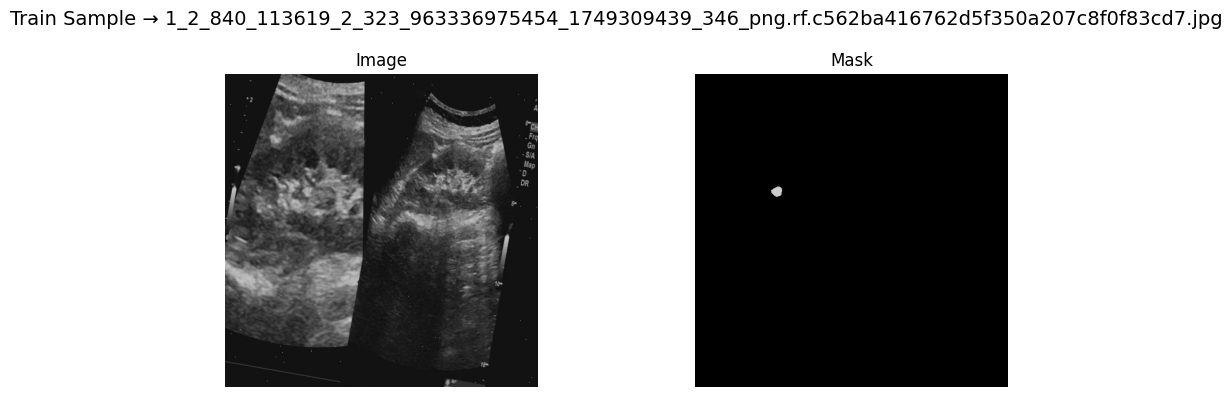

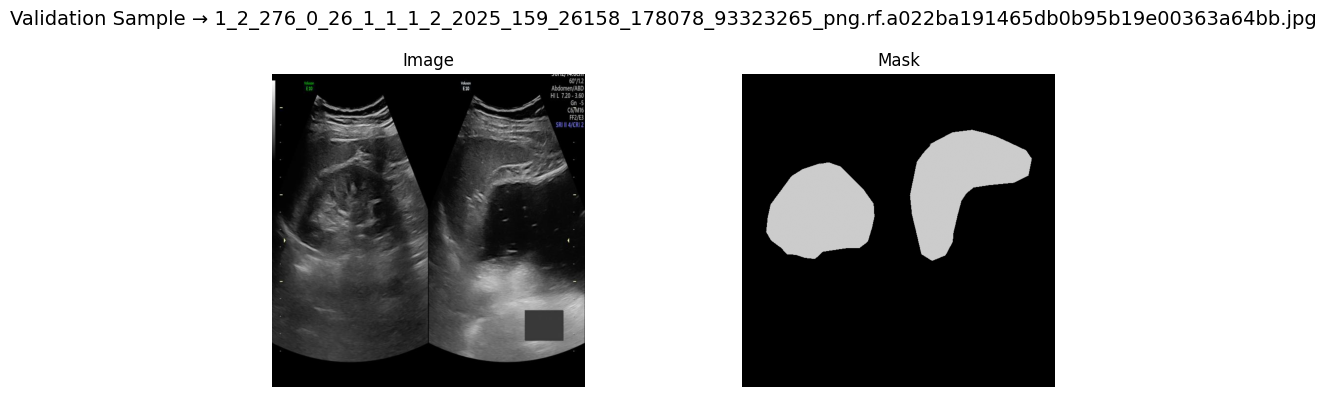

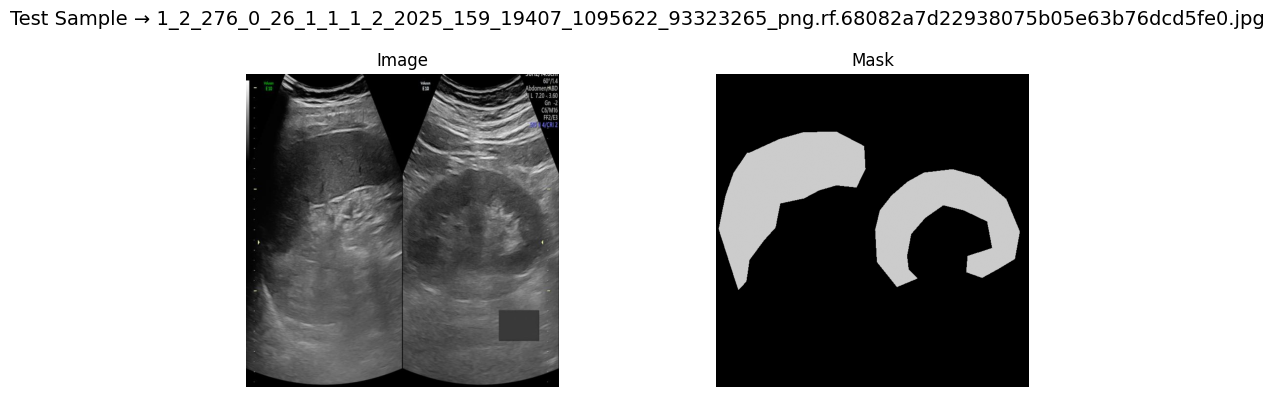

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

def visualize_random_pair(image_dir, mask_dir, title="Sample"):
    # Get all image filenames
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not image_files:
        print("No images found in:", image_dir)
        return

    # Randomly pick one
    image_name = random.choice(image_files)
    image_path = os.path.join(image_dir, image_name)

    # Derive corresponding mask path
    mask_name = image_name.replace(".jpg", ".png").replace(".jpeg", ".png")
    mask_path = os.path.join(mask_dir, mask_name)

    # Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Display
    plt.figure(figsize=(10, 4))
    plt.suptitle(title + f" → {image_name}", fontsize=14)

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="nipy_spectral")
    plt.title("Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


base_dir = "/content/Kidney_stone_detection-11"

# Visualize from training set
visualize_random_pair(
    image_dir=os.path.join(base_dir, "train"),
    mask_dir=os.path.join(base_dir, "train", "masks"),
    title="Train Sample"
)

# Visualize from validation set
visualize_random_pair(
    image_dir=os.path.join(base_dir, "valid"),
    mask_dir=os.path.join(base_dir, "valid", "masks"),
    title="Validation Sample"
)

# Visualize from test set
visualize_random_pair(
    image_dir=os.path.join(base_dir, "test"),
    mask_dir=os.path.join(base_dir, "test", "masks"),
    title="Test Sample"
)


In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir  # This now directly points to /train, /valid, etc.
        self.mask_dir = mask_dir
        self.transform = transform

        # List only image files
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx].rsplit(".", 1)[0] + ".png")  # Ensure extension match

        # Read image
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found or unreadable: {img_path}")
        image = cv2.resize(image, (640, 640))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found or unreadable: {mask_path}")
        mask = cv2.resize(mask, (640, 640), interpolation=cv2.INTER_NEAREST)

        # Apply transform
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        image = image / 255.0
        image = torch.tensor(image).permute(2, 0, 1).float()
        mask = torch.tensor(mask).long()

        return image, mask


In [ ]:
# Define directories
base_dir = "/content/Kidney_stone_detection-11"

train_dataset = SegmentationDataset(
    image_dir=os.path.join(base_dir, "train"),
    mask_dir=os.path.join(base_dir, "train", "masks")
)

val_dataset = SegmentationDataset(
    image_dir=os.path.join(base_dir, "valid"),
    mask_dir=os.path.join(base_dir, "valid", "masks")
)

test_dataset = SegmentationDataset(
    image_dir=os.path.join(base_dir, "test"),
    mask_dir=os.path.join(base_dir, "test", "masks")
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


In [ ]:
import segmentation_models_pytorch as smp

NUM_CLASSES = 13  # Update this based on your mask

model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
).to(device)
class_weights_tensor = torch.tensor(
    [0.0102, 0.0968, 0.0968, 0.0968, 0.0968, 0.0305, 0.0347,
     0.0539, 0.0968, 0.0769, 0.0611, 0.0683, 0.0366],
    dtype=torch.float
).to(device)

# Use two separate loss functions
dice_loss = smp.losses.DiceLoss(mode='multiclass')
ce_loss = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [ ]:
class_labels = {
    0: "Background",
    1: "cal",
    2: "calculus",
    3: "cyst",
    4: "gall bladder",
    5: "kidney",
    6: "liver",
    7: "ovary",
    8: "postvoid",
    9: "prevoid",
    10: "prostate",
    11: "spleen",
    12: "uterus"
}

In [ ]:
from tqdm import tqdm
from sklearn.metrics import jaccard_score, f1_score

EPOCHS = 25
best_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_dice = []
    train_iou = []

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        outputs = model(images)

        loss1 = dice_loss(outputs, masks)
        loss2 = ce_loss(outputs, masks)
        loss = loss1 + loss2
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        # Metrics
        preds = torch.argmax(outputs, dim=1)
        train_dice.append(f1_score(masks.flatten().cpu(), preds.flatten().cpu(), average='macro', zero_division=0))
        train_iou.append(jaccard_score(masks.flatten().cpu(), preds.flatten().cpu(), average='macro', zero_division=0))

    model.eval()
    val_loss = 0
    val_dice = []
    val_iou = []

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            loss1 = dice_loss(outputs, masks)
            loss2 = ce_loss(outputs, masks)
            loss = loss1 + loss2
            val_loss += loss.item()

            # Metrics
            preds = torch.argmax(outputs, dim=1)
            val_dice.append(f1_score(masks.flatten().cpu(), preds.flatten().cpu(), average='macro', zero_division=0))
            val_iou.append(jaccard_score(masks.flatten().cpu(), preds.flatten().cpu(), average='macro', zero_division=0))

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_dice = np.mean(train_dice)
    avg_val_dice = np.mean(val_dice)
    avg_train_iou = np.mean(train_iou)
    avg_val_iou = np.mean(val_iou)

    scheduler.step(avg_val_loss)

    print(f"\n📊 Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f}")
    print(f"Train IoU:  {avg_train_iou:.4f} | Val IoU:  {avg_val_iou:.4f}")
    print(f"Learning Rate: {scheduler.optimizer.param_groups[0]['lr']:.6f}")

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), "best_unet_model.pth")
        print("✅ Best model saved.\n")


Epoch 1 - Training:   0%|          | 0/606 [00:01<?, ?it/s]


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
import torch

model.load_state_dict(torch.load("best_unet_model.pth", map_location=device))
model.eval()


Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

In [ ]:
class_labels = {
    0: "Background",
    1: "cal",
    2: "calculus",
    3: "cyst",
    4: "gall bladder",
    5: "kidney",
    6: "liver",
    7: "ovary",
    8: "postvoid",
    9: "prevoid",
    10: "prostate",
    11: "spleen",
    12: "uterus"
}


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Generate distinct colors
num_classes = len(class_labels)
colors = plt.cm.get_cmap("tab20", num_classes).colors  # tab20 gives good distinct colors


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


In [ ]:
from sklearn.metrics import confusion_matrix

def calculate_iou(pred_mask, true_mask, num_classes):
    ious = []
    for cls in range(num_classes):
        pred = (pred_mask == cls)
        true = (true_mask == cls)
        intersection = (pred & true).sum()
        union = (pred | true).sum()
        if union == 0:
            ious.append(float('nan'))  # skip this class
        else:
            ious.append(intersection / union)
    return ious

def calculate_dice(pred_mask, true_mask, num_classes):
    dices = []
    for cls in range(num_classes):
        pred = (pred_mask == cls).astype(np.uint8)
        true = (true_mask == cls).astype(np.uint8)
        intersection = (pred * true).sum()
        if pred.sum() + true.sum() == 0:
            dices.append(float('nan'))
        else:
            dice_score = 2 * intersection / (pred.sum() + true.sum())
            dices.append(dice_score)
    return dices


In [ ]:
def visualize_prediction_with_metrics(model, dataset, idx=0, class_labels=class_labels):
    model.eval()
    image, true_mask = dataset[idx]
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image_input)
        pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy()

    true_mask_np = true_mask.cpu().numpy()
    ious = calculate_iou(pred_mask, true_mask_np, num_classes=len(class_labels))
    dices = calculate_dice(pred_mask, true_mask_np, num_classes=len(class_labels))

    # Visualization
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].imshow(image.permute(1, 2, 0).cpu().numpy())
    axs[0].set_title("Input Image")

    axs[1].imshow(true_mask_np, cmap='tab20', vmin=0, vmax=len(class_labels)-1)
    axs[1].set_title("Ground Truth Mask")

    axs[2].imshow(pred_mask, cmap='tab20', vmin=0, vmax=len(class_labels)-1)
    axs[2].set_title("Predicted Mask")

    # Add legend
    handles = [mpatches.Patch(color=colors[i], label=f"{i}: {class_labels[i]}") for i in range(len(class_labels))]
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Print metrics
    print("\nIoU and Dice per class:")
    for i, label in class_labels.items():
        iou_val = ious[i] if not np.isnan(ious[i]) else 0
        dice_val = dices[i] if not np.isnan(dices[i]) else 0
        print(f"Class {i} ({label}): IoU = {iou_val:.3f}, Dice = {dice_val:.3f}")

    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    valid_dices = [d for d in dices if not np.isnan(d)]
    print(f"\nMean IoU: {np.mean(valid_ious):.4f}")
    print(f"Mean Dice: {np.mean(valid_dices):.4f}")



🔍 Sample 1 — Index: 27


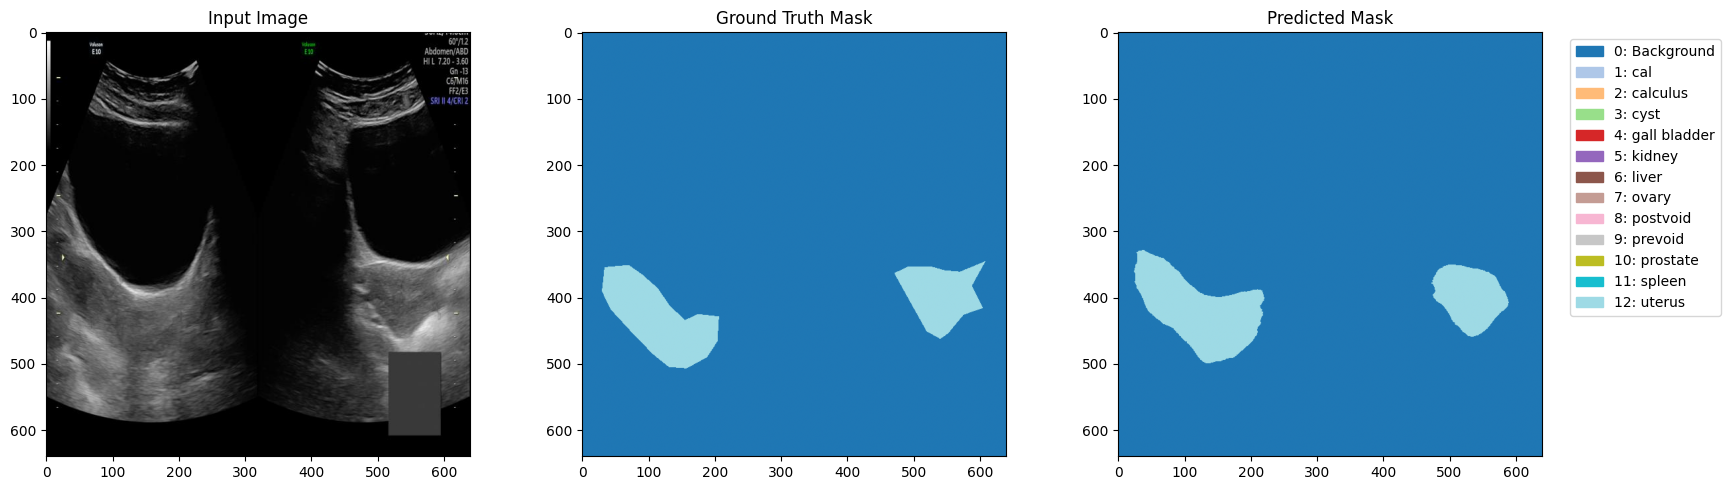


IoU and Dice per class:
Class 0 (Background): IoU = 0.980, Dice = 0.990
Class 1 (cal): IoU = 0.000, Dice = 0.000
Class 2 (calculus): IoU = 0.000, Dice = 0.000
Class 3 (cyst): IoU = 0.000, Dice = 0.000
Class 4 (gall bladder): IoU = 0.000, Dice = 0.000
Class 5 (kidney): IoU = 0.000, Dice = 0.000
Class 6 (liver): IoU = 0.000, Dice = 0.000
Class 7 (ovary): IoU = 0.000, Dice = 0.000
Class 8 (postvoid): IoU = 0.000, Dice = 0.000
Class 9 (prevoid): IoU = 0.000, Dice = 0.000
Class 10 (prostate): IoU = 0.000, Dice = 0.000
Class 11 (spleen): IoU = 0.000, Dice = 0.000
Class 12 (uterus): IoU = 0.723, Dice = 0.839

Mean IoU: 0.8514
Mean Dice: 0.9145

🔍 Sample 2 — Index: 2


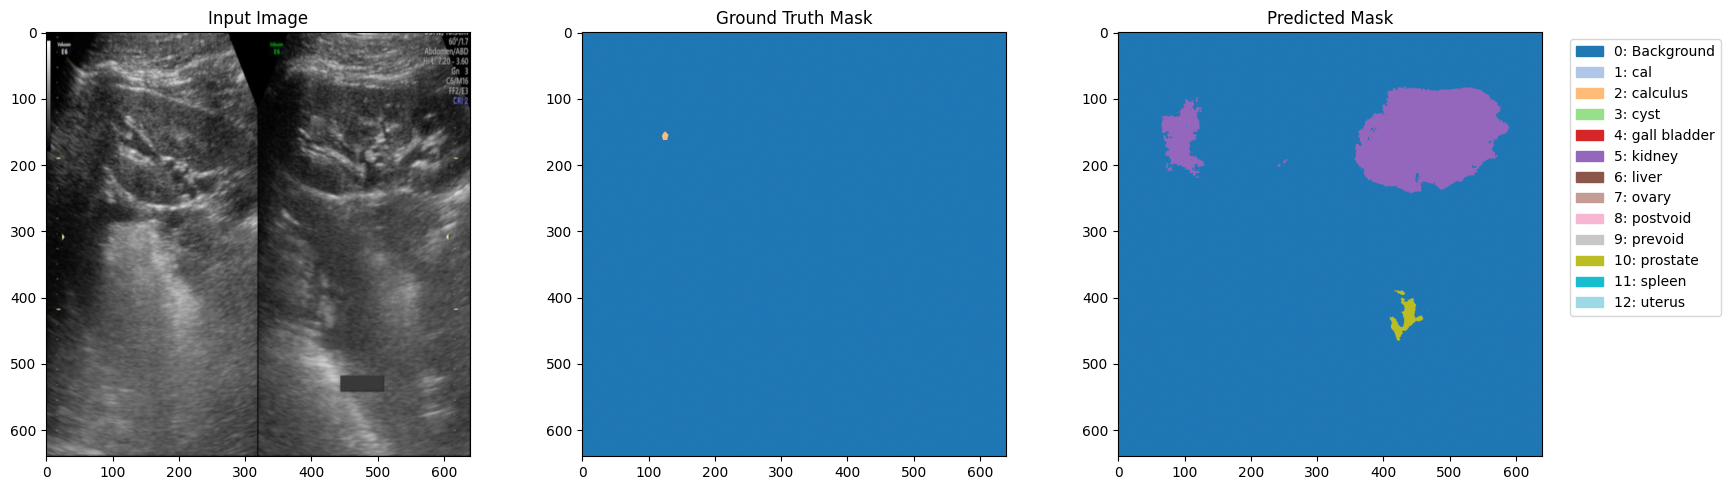


IoU and Dice per class:
Class 0 (Background): IoU = 0.921, Dice = 0.959
Class 1 (cal): IoU = 0.000, Dice = 0.000
Class 2 (calculus): IoU = 0.000, Dice = 0.000
Class 3 (cyst): IoU = 0.000, Dice = 0.000
Class 4 (gall bladder): IoU = 0.000, Dice = 0.000
Class 5 (kidney): IoU = 0.000, Dice = 0.000
Class 6 (liver): IoU = 0.000, Dice = 0.000
Class 7 (ovary): IoU = 0.000, Dice = 0.000
Class 8 (postvoid): IoU = 0.000, Dice = 0.000
Class 9 (prevoid): IoU = 0.000, Dice = 0.000
Class 10 (prostate): IoU = 0.000, Dice = 0.000
Class 11 (spleen): IoU = 0.000, Dice = 0.000
Class 12 (uterus): IoU = 0.000, Dice = 0.000

Mean IoU: 0.2302
Mean Dice: 0.2397

🔍 Sample 3 — Index: 14


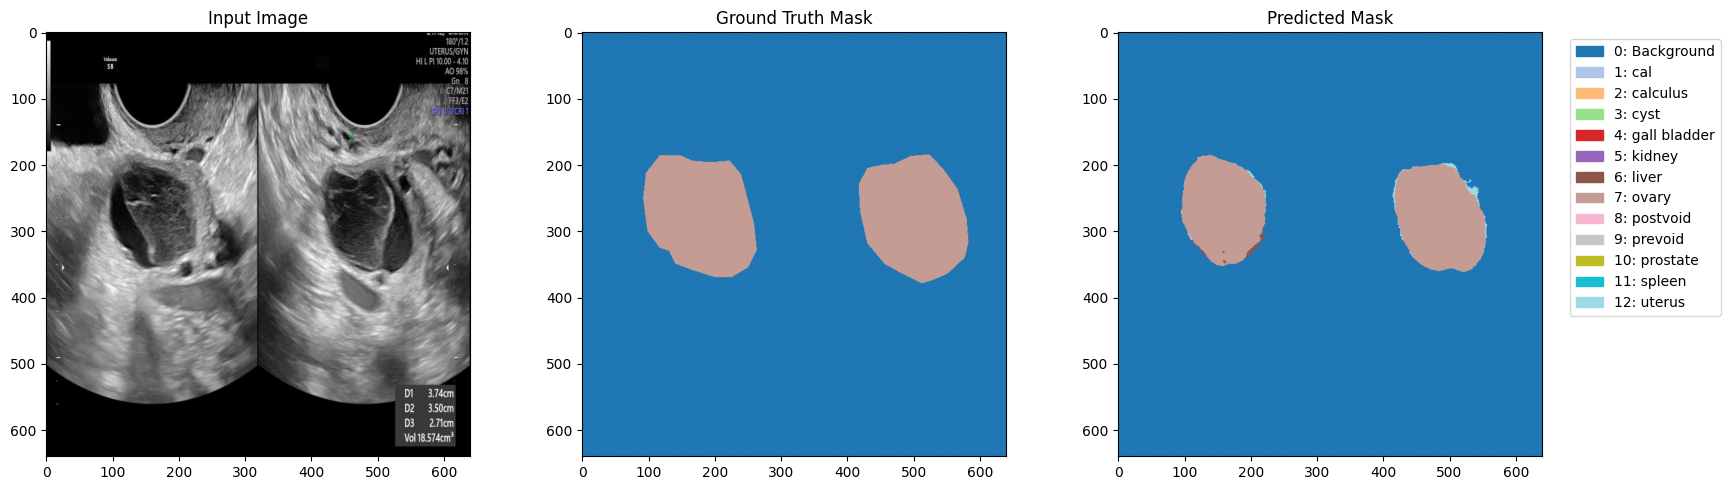


IoU and Dice per class:
Class 0 (Background): IoU = 0.960, Dice = 0.980
Class 1 (cal): IoU = 0.000, Dice = 0.000
Class 2 (calculus): IoU = 0.000, Dice = 0.000
Class 3 (cyst): IoU = 0.000, Dice = 0.000
Class 4 (gall bladder): IoU = 0.000, Dice = 0.000
Class 5 (kidney): IoU = 0.000, Dice = 0.000
Class 6 (liver): IoU = 0.000, Dice = 0.000
Class 7 (ovary): IoU = 0.682, Dice = 0.811
Class 8 (postvoid): IoU = 0.000, Dice = 0.000
Class 9 (prevoid): IoU = 0.000, Dice = 0.000
Class 10 (prostate): IoU = 0.000, Dice = 0.000
Class 11 (spleen): IoU = 0.000, Dice = 0.000
Class 12 (uterus): IoU = 0.000, Dice = 0.000

Mean IoU: 0.3285
Mean Dice: 0.3582

🔍 Sample 4 — Index: 17


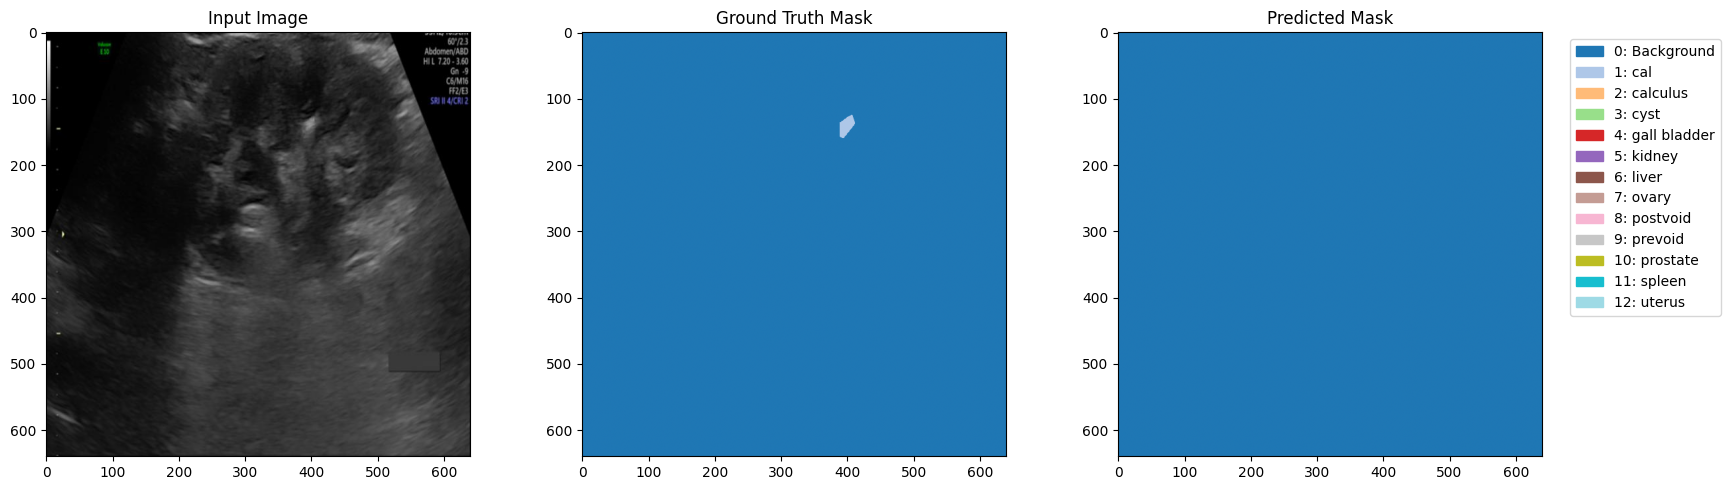


IoU and Dice per class:
Class 0 (Background): IoU = 0.999, Dice = 0.999
Class 1 (cal): IoU = 0.000, Dice = 0.000
Class 2 (calculus): IoU = 0.000, Dice = 0.000
Class 3 (cyst): IoU = 0.000, Dice = 0.000
Class 4 (gall bladder): IoU = 0.000, Dice = 0.000
Class 5 (kidney): IoU = 0.000, Dice = 0.000
Class 6 (liver): IoU = 0.000, Dice = 0.000
Class 7 (ovary): IoU = 0.000, Dice = 0.000
Class 8 (postvoid): IoU = 0.000, Dice = 0.000
Class 9 (prevoid): IoU = 0.000, Dice = 0.000
Class 10 (prostate): IoU = 0.000, Dice = 0.000
Class 11 (spleen): IoU = 0.000, Dice = 0.000
Class 12 (uterus): IoU = 0.000, Dice = 0.000

Mean IoU: 0.4994
Mean Dice: 0.4997

🔍 Sample 5 — Index: 15


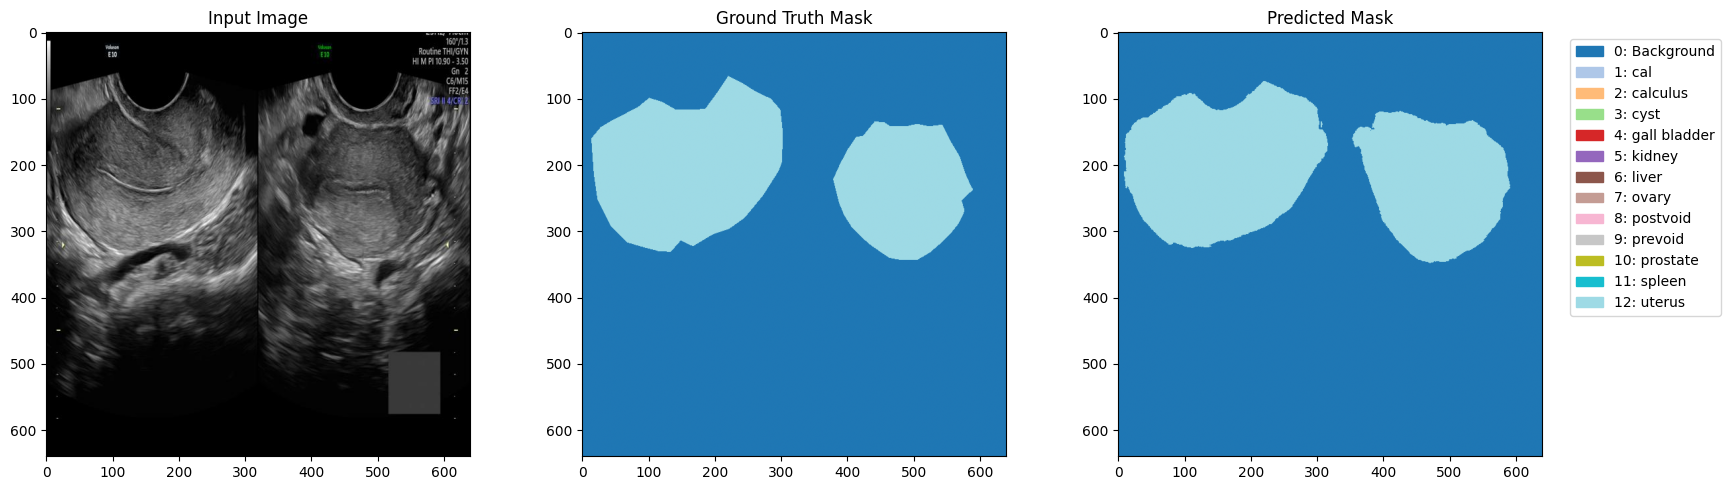


IoU and Dice per class:
Class 0 (Background): IoU = 0.969, Dice = 0.984
Class 1 (cal): IoU = 0.000, Dice = 0.000
Class 2 (calculus): IoU = 0.000, Dice = 0.000
Class 3 (cyst): IoU = 0.000, Dice = 0.000
Class 4 (gall bladder): IoU = 0.000, Dice = 0.000
Class 5 (kidney): IoU = 0.000, Dice = 0.000
Class 6 (liver): IoU = 0.000, Dice = 0.000
Class 7 (ovary): IoU = 0.000, Dice = 0.000
Class 8 (postvoid): IoU = 0.000, Dice = 0.000
Class 9 (prevoid): IoU = 0.000, Dice = 0.000
Class 10 (prostate): IoU = 0.000, Dice = 0.000
Class 11 (spleen): IoU = 0.000, Dice = 0.000
Class 12 (uterus): IoU = 0.894, Dice = 0.944

Mean IoU: 0.9315
Mean Dice: 0.9641


In [ ]:
# Test on any sample from your test set
import random

# Number of random samples to visualize
num_samples = 5
indices = random.sample(range(len(test_dataset)), num_samples)

for i, idx in enumerate(indices):
    print(f"\n🔍 Sample {i+1} — Index: {idx}")
    visualize_prediction_with_metrics(model, test_dataset, idx=idx)



In [ ]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np

# === Set model to evaluation mode ===
model.eval()

# === Initialize accumulators ===
all_preds = []
all_targets = []

with torch.no_grad():
    for images, masks in val_loader:  # or test_loader if you have one
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        # Flatten predictions and ground truths
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(masks.cpu().numpy().flatten())

# === Convert to NumPy arrays ===
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# === Define class labels ===
class_labels = {
    0: "Background",
    1: "cal",
    2: "calculus",
    3: "cyst",
    4: "gall bladder",
    5: "kidney",
    6: "liver",
    7: "ovary",
    8: "postvoid",
    9: "prevoid",
    10: "prostate",
    11: "spleen",
    12: "uterus"
}
label_ids = list(class_labels.keys())

# === Overall Metrics (macro average) ===
precision_macro = precision_score(all_targets, all_preds, average='macro', zero_division=0)
recall_macro = recall_score(all_targets, all_preds, average='macro', zero_division=0)
f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)

print(f"\n📊 Final Evaluation Metrics (Macro Average):")
print(f"Precision: {precision_macro:.4f}")
print(f"Recall:    {recall_macro:.4f}")
print(f"F1 Score:  {f1_macro:.4f}")

# === Per-Class Scores ===
precision_per_class = precision_score(all_targets, all_preds, labels=label_ids, average=None, zero_division=0)
recall_per_class = recall_score(all_targets, all_preds, labels=label_ids, average=None, zero_division=0)
f1_per_class = f1_score(all_targets, all_preds, labels=label_ids, average=None, zero_division=0)

print("\n📌 Per-Class Metrics:")
for i, label_id in enumerate(label_ids):
    print(f"{class_labels[label_id]:<15} | Precision: {precision_per_class[i]:.4f} | Recall: {recall_per_class[i]:.4f} | F1: {f1_per_class[i]:.4f}")

# === Optional Detailed Report ===
try:
    report = classification_report(
        all_targets,
        all_preds,
        labels=label_ids,
        target_names=[class_labels[i] for i in label_ids],
        digits=3,
        zero_division=0
    )
    print("\n🧾 Detailed Classification Report:\n")
    print(report)
except Exception as e:
    print("⚠️ Could not print detailed report:", str(e))



📊 Final Evaluation Metrics (Macro Average):
Precision: 0.5546
Recall:    0.5398
F1 Score:  0.5445

📌 Per-Class Metrics:
Background      | Precision: 0.9680 | Recall: 0.9749 | F1: 0.9714
cal             | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
calculus        | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
cyst            | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
gall bladder    | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
kidney          | Precision: 0.7066 | Recall: 0.5442 | F1: 0.6148
liver           | Precision: 0.9184 | Recall: 0.7888 | F1: 0.8487
ovary           | Precision: 0.6922 | Recall: 0.6018 | F1: 0.6438
postvoid        | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
prevoid         | Precision: 0.6878 | Recall: 0.8364 | F1: 0.7548
prostate        | Precision: 0.6436 | Recall: 0.6481 | F1: 0.6458
spleen          | Precision: 0.7408 | Recall: 0.7058 | F1: 0.7229
uterus          | Precision: 0.7433 | Recall: 0.8374 | F1: 0.7876

🧾 Detailed Classific